# EDA и подготовка данных
Датасет: Intel Image Classification

Цель: исследовать данные, выделить train/val, подготовить метаинформацию.

In [1]:
import os
import shutil
import random
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from sklearn.model_selection import train_test_split
import pandas as pd

## Пути

In [2]:
DATA_DIR = Path("../data/raw/seg_train/seg_train")   # папка с train из датасета
TEST_DIR = Path("../data/raw/seg_test/seg_test")     # папка с test из датасета
NEW_VAL_DIR = Path("../data/processed/val")          # куда сохраним валидацию
NEW_TRAIN_DIR = Path("../data/processed/train")      # куда сохраним train
os.makedirs(NEW_VAL_DIR, exist_ok=True)
os.makedirs(NEW_TRAIN_DIR, exist_ok=True)

## Получаем список классов

In [3]:
classes = sorted([d.name for d in DATA_DIR.iterdir() if d.is_dir()])
print("Классы:", classes)

Классы: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


## Подсчёт изображений в train и test

In [4]:
train_counts = {}
for cls in classes:
    train_counts[cls] = len(list((DATA_DIR / cls).glob("*.jpg")))
test_counts = {}
for cls in classes:
    test_counts[cls] = len(list((TEST_DIR / cls).glob("*.jpg")))

print("Train counts:", train_counts)
print("Test counts:", test_counts)

Train counts: {'buildings': 2191, 'forest': 2271, 'glacier': 2404, 'mountain': 2512, 'sea': 2274, 'street': 2382}
Test counts: {'buildings': 437, 'forest': 474, 'glacier': 553, 'mountain': 525, 'sea': 510, 'street': 501}


## Визуализация распределения

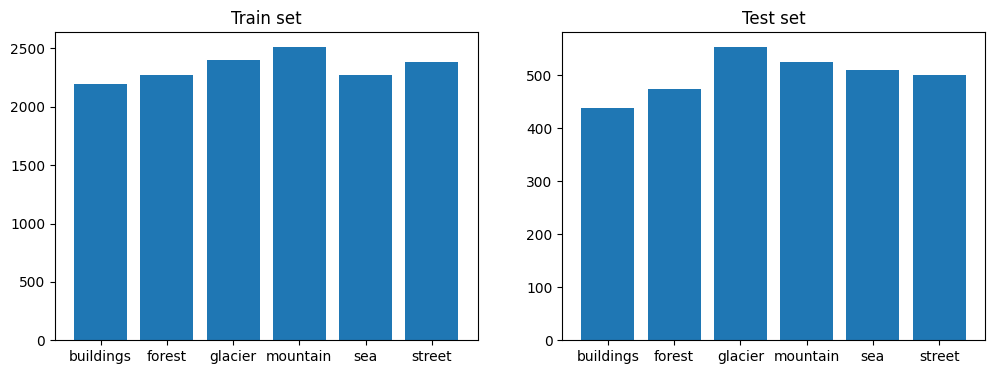

In [5]:
fig, ax = plt.subplots(1,2, figsize=(12,4))
ax[0].bar(train_counts.keys(), train_counts.values())
ax[0].set_title("Train set")
ax[1].bar(test_counts.keys(), test_counts.values())
ax[1].set_title("Test set")
plt.show()

## Разделим train на train/val (80/20) с сохранением пропорций

In [6]:
val_ratio = 0.2
for cls in classes:
    src_dir = DATA_DIR / cls
    images = list(src_dir.glob("*.jpg"))
    train_imgs, val_imgs = train_test_split(images, test_size=val_ratio, random_state=42)
    
    dst_train_dir = NEW_TRAIN_DIR / cls
    dst_val_dir = NEW_VAL_DIR / cls
    dst_train_dir.mkdir(parents=True, exist_ok=True)
    dst_val_dir.mkdir(parents=True, exist_ok=True)
    
    for img in train_imgs:
        shutil.copy(img, dst_train_dir / img.name)
    for img in val_imgs:
        shutil.copy(img, dst_val_dir / img.name)

print("Done. Train/Val split created.")

Done. Train/Val split created.


## Проверка размеров изображений

In [7]:
sample_img = Image.open(next(iter((DATA_DIR / classes[0]).glob("*.jpg"))))
print("Размер изображения:", sample_img.size)
print("Режим:", sample_img.mode)

Размер изображения: (150, 150)
Режим: RGB


## Несколько примеров

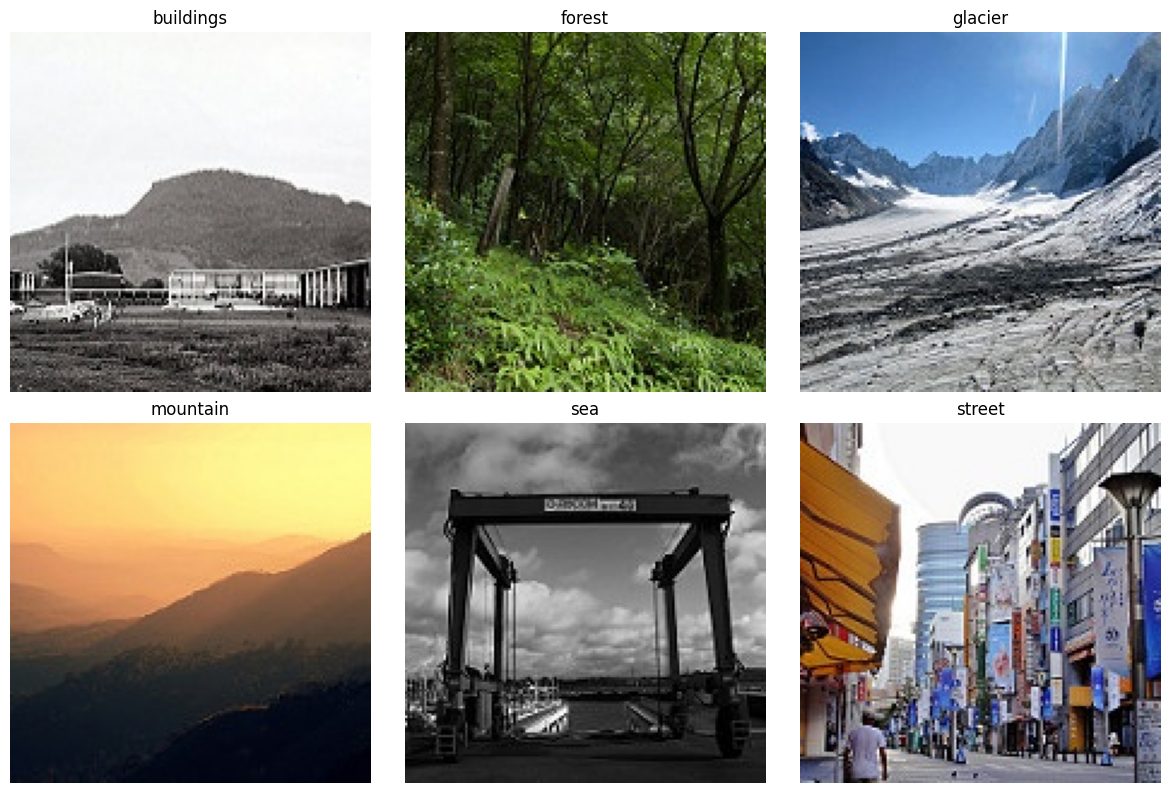

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(12,8))
for i, cls in enumerate(classes):
    img_path = list((DATA_DIR / cls).glob("*.jpg"))[0]
    img = Image.open(img_path)
    axes[i//3, i%3].imshow(img)
    axes[i//3, i%3].set_title(cls)
    axes[i//3, i%3].axis('off')
plt.tight_layout()
plt.show()